# 05 - Model Training

## Objective

This notebook trains Random Forest and XGBoost regression pipelines to predict `quantity_sold`. Both models use the same features and the same temporal split. Their results are compared with the simple baselines.

**Input:** `data/processed/modeling_dataset.csv` and `reports/baseline_results.csv`  
**Outputs:** trained pipelines in `artifacts/models/` and `reports/model_training_results.csv`  
**Next notebook:** `06_model_evaluation.ipynb`

## Imports and Load Dataset

In [1]:
import os
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import sys
import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

sys.path.append(str(ROOT))
from src.evaluation import evaluate_forecast
from src.importance import get_feature_importance

DATA_PATH = ROOT / "data" / "processed" / "modeling_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
print("Shape:", df.shape)

Shape: (6000, 15)


## Define Target and Features

In [2]:
target = "quantity_sold"
numeric_features = [
    "unit_price_1d", "day_of_week", "day_of_month", "month",
    "week_of_year", "is_weekend", "quantity_1d", "quantity_7d",
    "quantity_14d", "rolling_1d", "rolling_7d", "rolling_14d",
]
categorical_features = ["product_name"]
feature_columns = numeric_features + categorical_features

assert target not in feature_columns
assert set(feature_columns).issubset(df.columns)

## Temporal Train/Test Split

The oldest 80% of unique dates are used for training and the newest 20% for testing. Splitting by date keeps every product on a date in the same set. There is no shuffle.

In [3]:
unique_dates = df["sale_date"].sort_values().unique()
split_index = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]

train = df[df["sale_date"].isin(train_dates)].copy()
test = df[df["sale_date"].isin(test_dates)].copy()

assert train["sale_date"].max() < test["sale_date"].min()
assert set(train["sale_date"]).isdisjoint(set(test["sale_date"]))

X_train = train[feature_columns]
y_train = train[target]
X_test = test[feature_columns]
y_test = test[target].to_numpy()

print("Train period:", train["sale_date"].min(), "to", train["sale_date"].max())
print("Test period:", test["sale_date"].min(), "to", test["sale_date"].max())
print("Train rows:", len(train), "Test rows:", len(test))

Train period: 2025-01-15 00:00:00 to 2026-02-18 00:00:00
Test period: 2026-02-19 00:00:00 to 2026-05-29 00:00:00
Train rows: 4800 Test rows: 1200


## Build the Preprocessor

Numeric values pass through unchanged. Product names are one-hot encoded. Unknown product categories can be ignored when the saved pipeline is reused.

In [4]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

## Train Random Forest

The settings use many small decision trees and require at least two rows in each final leaf. No large tuning search is used.

In [5]:
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )),
])
rf_pipe.fit(X_train, y_train)
y_pred_rf_raw = rf_pipe.predict(X_test)
y_pred_rf = np.clip(y_pred_rf_raw, 0, None)
rf_results = evaluate_forecast(y_test, y_pred_rf)
print("Negative Random Forest predictions clipped:", int((y_pred_rf_raw < 0).sum()))
pd.Series(rf_results).round(2)

Negative Random Forest predictions clipped: 0


MAE      1.32
RMSE     1.85
MAPE    63.50
WAPE    81.85
dtype: float64

## Train XGBoost

The learning rate is small and the tree depth is limited to reduce overly complex trees. The settings remain simple and no advanced hyperparameter tuning is performed.

In [6]:
xgb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=4,
        min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
        gamma=0.1, reg_alpha=0.1, reg_lambda=2.0,
        objective="reg:squarederror", eval_metric="rmse", tree_method="hist",
        random_state=42, n_jobs=-1,
    )),
])
xgb_pipe.fit(X_train, y_train)
y_pred_xgb_raw = xgb_pipe.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb_raw, 0, None)
xgb_results = evaluate_forecast(y_test, y_pred_xgb)
print("Negative XGBoost predictions clipped:", int((y_pred_xgb_raw < 0).sum()))
pd.Series(xgb_results).round(2)

Negative XGBoost predictions clipped: 1


MAE      1.30
RMSE     1.87
MAPE    62.58
WAPE    80.29
dtype: float64

## Compare Models and Baselines

In [7]:
model_results_df = pd.DataFrame([
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results},
])
baseline_results_df = pd.read_csv(ROOT / "reports" / "baseline_results.csv")
comparison_df = pd.concat([baseline_results_df, model_results_df], ignore_index=True)
comparison_df.round(2).sort_values("MAE")

,Model,MAE,RMSE,MAPE,WAPE
3,XGBoost,1.30,1.87,62.58,80.29
2,Random Forest,1.32,1.85,63.50,81.85
1,7-Day Moving Average,1.35,1.93,66.29,83.55
0,Last Value,1.66,2.48,94.93,102.99


## Visualize Predictions

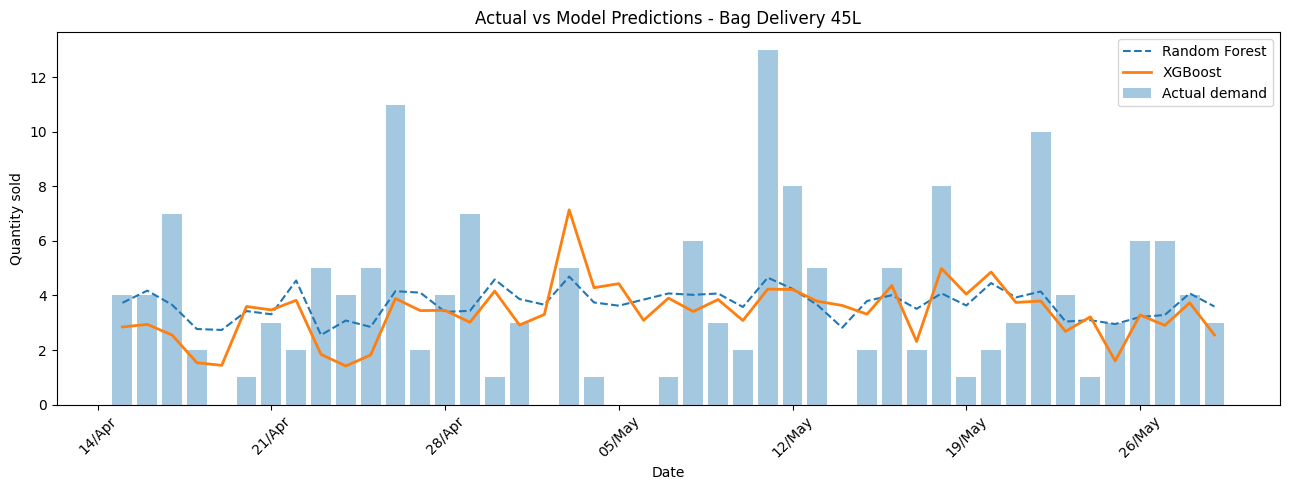

In [8]:
eval_df = test[["sale_date", "product_name", "quantity_sold"]].reset_index(drop=True).copy()
eval_df["rf_prediction"] = y_pred_rf
eval_df["xgb_prediction"] = y_pred_xgb

product_name = "Bag Delivery 45L"
plot_df = eval_df[eval_df["product_name"] == product_name].sort_values("sale_date").tail(45)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(plot_df["sale_date"], plot_df["quantity_sold"], alpha=0.4, label="Actual demand")
ax.plot(plot_df["sale_date"], plot_df["rf_prediction"], "--", label="Random Forest")
ax.plot(plot_df["sale_date"], plot_df["xgb_prediction"], linewidth=2, label="XGBoost")
ax.set_title(f"Actual vs Model Predictions - {product_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity sold")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

In [9]:
rf_importance = get_feature_importance(rf_pipe)
xgb_importance = get_feature_importance(xgb_pipe)

display(rf_importance.head(10).rename(columns={"importance": "random_forest_importance"}))
display(xgb_importance.head(10).rename(columns={"importance": "xgboost_importance"}))

,feature,random_forest_importance
0,rolling_14d,0.328576
1,unit_price_1d,0.149991
2,day_of_month,0.094290
3,week_of_year,0.080171
4,rolling_7d,0.073467
5,quantity_14d,0.054856
6,quantity_7d,0.053751
7,day_of_week,0.046819
8,quantity_1d,0.027729
9,rolling_1d,0.027370


,feature,xgboost_importance
0,rolling_14d,0.157461
1,product_name_Bag Delivery 45L,0.083745
2,product_name_Suporte Celular Moto,0.054184
3,product_name_Capa de Chuva,0.054011
4,rolling_7d,0.048121
5,week_of_year,0.044779
6,is_weekend,0.043182
7,product_name_Capacete LS2,0.043175
8,unit_price_1d,0.042832
9,month,0.038963


## Save Full Pipelines and Results

In [10]:
MODELS_PATH = ROOT / "artifacts" / "models"
MODELS_PATH.mkdir(parents=True, exist_ok=True)
joblib.dump(rf_pipe, MODELS_PATH / "random_forest_model.pkl")
joblib.dump(xgb_pipe, MODELS_PATH / "xgboost_model.pkl")

RESULTS_PATH = ROOT / "reports" / "model_training_results.csv"
model_results_df.to_csv(RESULTS_PATH, index=False, encoding="utf-8")

print("Saved model pipelines to:", MODELS_PATH.resolve())
print("Saved model results to:", RESULTS_PATH.resolve())

Saved model pipelines to: C:\DEV\motostock-ai\artifacts\models
Saved model results to: C:\DEV\motostock-ai\reports\model_training_results.csv


## Summary

Random Forest and XGBoost were trained on the same full-date temporal split. In this run, XGBoost has the lower MAE, while Random Forest has a slightly lower RMSE. The results are close, so the comparison should not be exaggerated. The saved files contain the complete preprocessing and model pipelines, so later notebooks receive the same columns in the same form.

MAE is the main metric because it is measured in units sold. RMSE gives more weight to large errors. MAPE is reported but should be read carefully because zero targets are excluded and small targets can create large percentages.

The next notebook reloads both saved pipelines, recreates the same test set and performs a more detailed evaluation by product.